## Data Loading and Preprocessing

This code block handles the uploading of your CSV file, reads it into a pandas DataFrame, performs initial data cleaning by removing specific system columns (`system:index`, `.geo`) and rows with missing values, and then separates the features (`X`) from the target variable (`y`). Finally, it splits the data into training and testing sets for model development.

In [1]:
import pandas as pd
import io
from google.colab import files
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

# 1. This will trigger a "Choose Files" button right in the notebook
print("Please upload your CSV file:")
uploaded = files.upload()

# 2. Get the exact filename automatically (in case you renamed it)
file_name = list(uploaded.keys())[0]

# 3. Read the uploaded file into a Pandas DataFrame
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# 4. Clean the data (GEE exports system:index, which we don't need)
if 'system:index' in df.columns:
    df = df.drop(columns=['system:index'])
if '.geo' in df.columns:
    df = df.drop(columns=['.geo'])

# Drop any rows where GEE might have sampled a masked pixel (NaNs)
df = df.dropna()

# 5. Separate Features (X) and Target Label (y)
# (Assuming your land cover column is named 'class')
X = df.drop(columns=['Map'])
y = df['Map']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"\nData loaded successfully! Training on {X_train.shape[1]} features.")





Please upload your CSV file:


Saving Suam_Training_Points_Region_CP2.csv to Suam_Training_Points_Region_CP2.csv

Data loaded successfully! Training on 82 features.


## Model Definition and Training

This cell defines and trains three classification models: Random Forest, Gradient Boosting (using XGBoost), and CART. It also adjusts target labels to be 0-indexed as required by XGBoost for proper model training.

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier # <-- The fix for Gradient Boosting

# 1. XGBoost strictly requires labels to start at 0 (so 1-6 becomes 0-5)
y_train_adj = y_train - 1
y_test_adj = y_test - 1

# 2. Define the models mimicking your exact GEE hyperparameters
models = {
    "Random Forest (Winner)": RandomForestClassifier(
        n_estimators=100,
        max_features=5,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting (Challenger)": XGBClassifier( # Swapped to XGBoost
        n_estimators=50,
        learning_rate=0.05,
        subsample=0.7,
        random_state=42,
        eval_metric='mlogloss'
    ),
    "CART (Baseline)": DecisionTreeClassifier(
        random_state=42
    )
}

# 3. Retrain models with the adjusted labels (0-5)
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train_adj)

Training Random Forest (Winner)...
Training Gradient Boosting (Challenger)...
Training CART (Baseline)...


## Install SHAP

### Subtask:
Install the SHAP library in the current Colab environment.

In [3]:
pip install shap

## Calculate SHAP Values

### Subtask:
Select the 'Random Forest (Winner)' model, initialize a SHAP TreeExplainer, and compute SHAP values for the test dataset.

In [4]:
import shap

# 1. Access the trained 'Random Forest (Winner)' model
rf_model = models["Random Forest (Winner)"]

# 3. Initialize a shap.TreeExplainer object
explainer = shap.TreeExplainer(rf_model)

# 4. Calculate the SHAP values for the X_test dataset
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully.")

SHAP values calculated successfully.


This cell re-defines and re-trains the classification models, ensuring the 'models' dictionary and the 'Random Forest (Winner)' model are accessible and updated for subsequent SHAP value calculations.

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier # <-- The fix for Gradient Boosting

# 1. XGBoost strictly requires labels to start at 0 (so 1-6 becomes 0-5)
y_train_adj = y_train - 1
y_test_adj = y_test - 1

# 2. Define the models mimicking your exact GEE hyperparameters
models = {
    "Random Forest (Winner)": RandomForestClassifier(
        n_estimators=100,
        max_features=5,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting (Challenger)": XGBClassifier( # Swapped to XGBoost
        n_estimators=50,
        learning_rate=0.05,
        subsample=0.7,
        random_state=42,
        eval_metric='mlogloss'
    ),
    "CART (Baseline)": DecisionTreeClassifier(
        random_state=42
    )
}

# 3. Retrain models with the adjusted labels (0-5)
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train_adj)

Training Random Forest (Winner)...
Training Gradient Boosting (Challenger)...
Training CART (Baseline)...


This cell calculates and visualizes class-specific SHAP feature importance for all trained models. It uses custom class names and colors to generate stacked bar charts for the top features, providing insights into feature contributions for each land cover class.


Calculating SHAP values for Random Forest (Winner)...


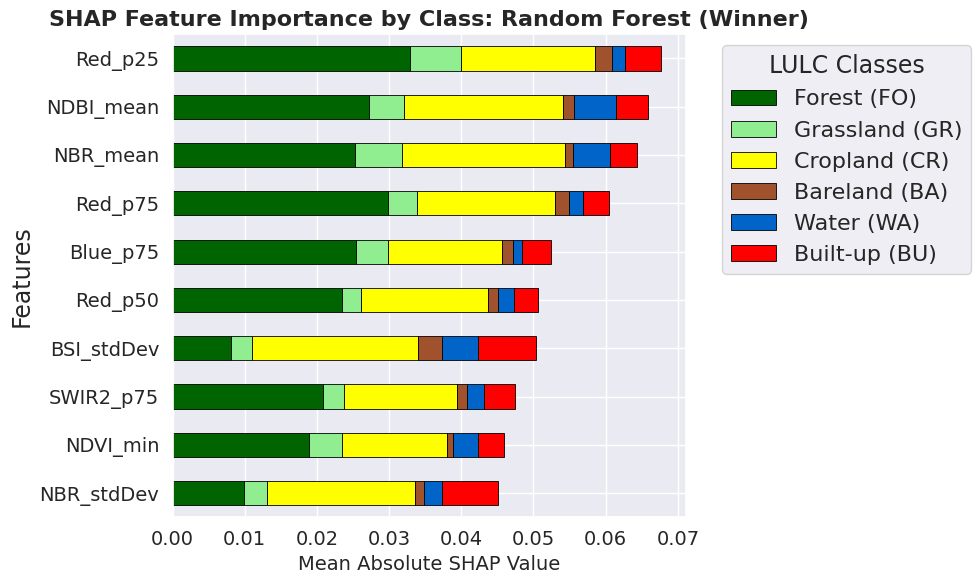


Calculating SHAP values for Gradient Boosting (Challenger)...


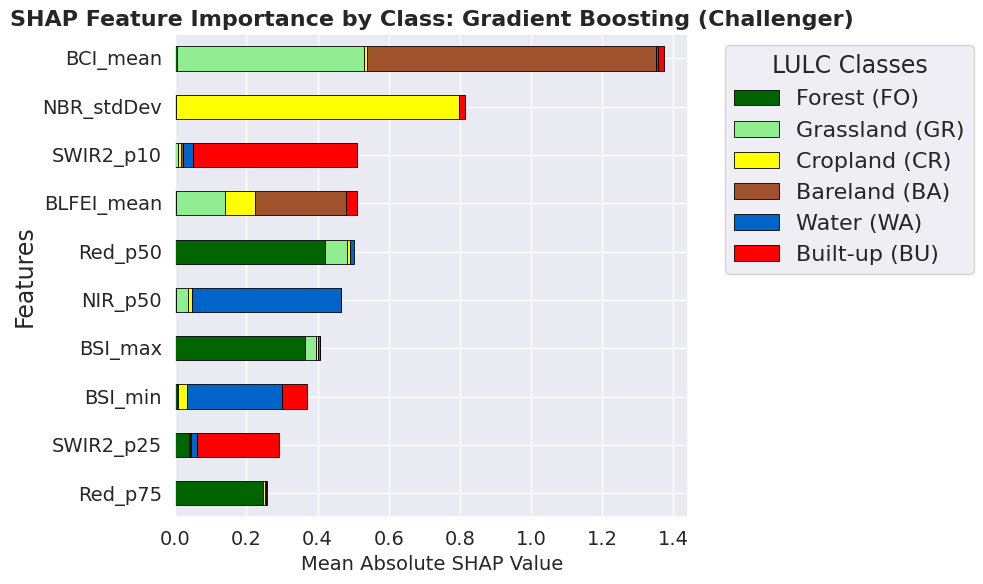


Calculating SHAP values for CART (Baseline)...


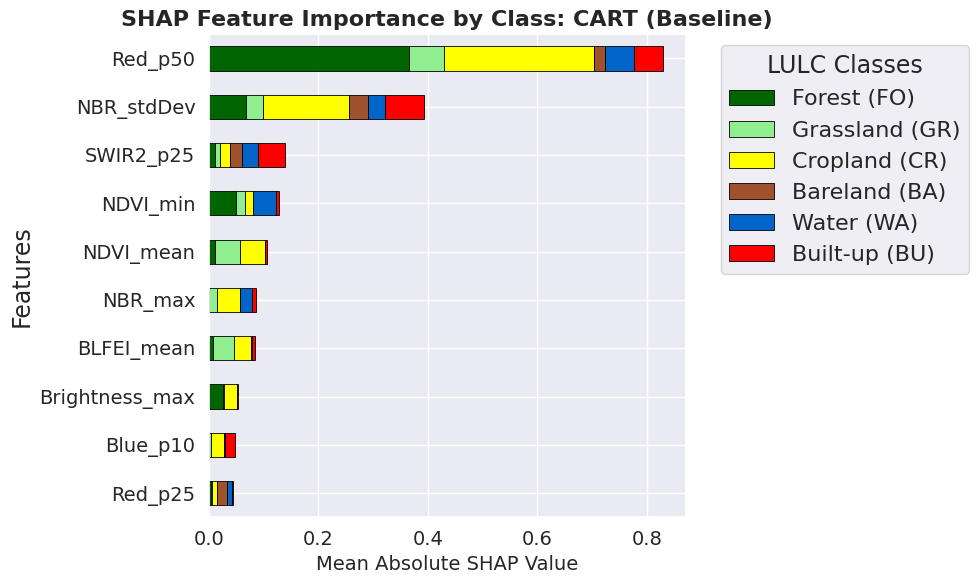

In [ ]:
# ==========================================
# CELL 3: SHAP MULTI-CLASS (BULLETPROOF CUSTOM COLORS)
# ==========================================
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns # Added seaborn for enhanced aesthetics

# Apply a seaborn theme for better aesthetics
sns.set_theme()

# 1. Class Names and Exact QGIS Hex Colors
class_names = ['Forest (FO)', 'Grassland (GR)', 'Cropland (CR)', 'Bareland (BA)', 'Water (WA)', 'Built-up (BU)']
class_colors = ['#006400', '#90ee90', '#ffff00', '#a0522d', '#0064c8', '#ff0000']

# Take a random sample to save time
X_sub = X_test.sample(min(1000, len(X_test)), random_state=42)

# Dictionary to store SHAP DataFrames for each model
all_shap_dfs = {}

num_models = len(models) # Get the total number of models
for i, (name, model) in enumerate(models.items()): # Use enumerate to get index
    print(f"\nCalculating SHAP values for {name}...")

    # 2. Calculate SHAP values
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sub)

    # 3. Robust Extraction Logic
    if isinstance(shap_values, list):
        shap_list = shap_values
    elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
        shap_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
    elif hasattr(shap_values, 'values') and len(shap_values.values.shape) == 3:
        shap_list = [shap_values.values[:, :, i] for i in range(shap_values.values.shape[2])]
    else:
        shap_list = shap_values

    # 4. Extract Mean Absolute SHAP values for our custom chart
    # This calculates exactly what SHAP's summary_plot calculates internally
    mean_shap_values = np.array([np.abs(c_shap).mean(axis=0) for c_shap in shap_list])

    # Put it into a Pandas DataFrame for easy plotting
    df_shap = pd.DataFrame(mean_shap_values.T, columns=class_names, index=X_sub.columns)

    # Calculate the total importance across all classes to find the Top 15 features
    df_shap['Total_Importance'] = df_shap.sum(axis=1)
    df_shap_top15 = df_shap.sort_values(by='Total_Importance', ascending=True).tail(10)

    # Drop the total column before plotting
    df_shap_top15 = df_shap_top15.drop(columns=['Total_Importance'])

    # Store the final df_shap_top15 for export
    all_shap_dfs[name] = df_shap_top15

    # 5. Build the Custom Stacked Bar Chart
    fig, ax = plt.subplots(figsize=(10, 6))

    df_shap_top15.plot(
        kind='barh',
        stacked=True,
        color=class_colors,
        ax=ax,
        edgecolor='black', # Adds a clean border to the bars
        linewidth=0.6
    )

    # Formatting for a publication-ready look
    ax.set_title(f"SHAP Feature Importance by Class: {name}", fontsize=16, fontweight='bold') # Increased font
    ax.set_xlabel("Mean Absolute SHAP Value", fontsize=14) # Increased font
    ax.set_ylabel("Features", fontsize=17) # Increased font

    # Increase font size for y-axis (feature names) tick labels and x-axis values
    ax.tick_params(axis='y', labelsize=14)
    ax.tick_params(axis='x', labelsize=14)

    # Adjust subplot to make space for the legend *before* tight_layout
    plt.subplots_adjust(right=0.7) # Make room for the legend on the right
    ax.legend(title="LULC Classes", fontsize=16, title_fontsize=17, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

## Export Global SHAP Feature Importance to CSV

This cell calculates and exports the global SHAP feature importance for each trained model to separate CSV files, providing an overall ranking of feature impact.

In [24]:
import numpy as np
import pandas as pd
import shap # Import shap for TreeExplainer

print("Exporting global SHAP feature importance for all models to CSV...")

# Ensure feature names are available
feature_names = X_test.columns.tolist()

# Initialize shap_values_dict to store raw SHAP values for each model
shap_values_dict = {}

# Calculate SHAP values for all models and store them in shap_values_dict
# This ensures all models are considered for global importance export
for name, model in models.items():
    print(f"  Calculating raw SHAP values for {name}...")
    explainer = shap.TreeExplainer(model)
    # Using X_test for consistency, as `shap_values` was previously generated for X_test
    current_model_shap_values = explainer.shap_values(X_test)
    shap_values_dict[name] = current_model_shap_values

print("Raw SHAP values for all models calculated.")

# Dictionary to store global importance DataFrames
global_importance_dfs = {}

for model_name, current_shap_values in shap_values_dict.items():
    print(f"  Calculating global importance for model: {model_name}")

    if isinstance(current_shap_values, list):
        # For models where shap_values is a list of arrays (n_classes elements, each (n_samples, n_features))
        # Stack them to get (n_samples, n_features, n_classes)
        combined_shap_values = np.stack(current_shap_values, axis=-1)
    elif current_shap_values.ndim == 3:
        # For models where shap_values is already a 3D array (n_samples, n_features, n_classes)
        combined_shap_values = current_shap_values
    else:
        print(f"    Warning: SHAP values for {model_name} are not in an expected multi-output format (2D array). Skipping global importance calculation.")
        continue

    # Calculate mean absolute SHAP value across samples, summing absolute values across classes
    # This approximates the global importance as displayed in summary_plot (bar type)
    global_importance_values = np.mean(np.sum(np.abs(combined_shap_values), axis=2), axis=0)

    # Create a DataFrame for global importance
    global_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Global_SHAP_Importance': global_importance_values
    })
    global_importance_df = global_importance_df.sort_values(by='Global_SHAP_Importance', ascending=False).reset_index(drop=True)

    global_importance_dfs[model_name] = global_importance_df

    # Export to CSV
    filename = f"global_shap_importance_{model_name.replace(' ', '_').replace('(', '').replace(')', '')}.csv"
    global_importance_df.to_csv(filename, index=False)
    print(f"    Exported {filename}")

print("All global SHAP feature importance values exported successfully.")

Exporting global SHAP feature importance for all models to CSV...
  Calculating raw SHAP values for Random Forest (Winner)...
  Calculating raw SHAP values for Gradient Boosting (Challenger)...
  Calculating raw SHAP values for CART (Baseline)...
Raw SHAP values for all models calculated.
  Calculating global importance for model: Random Forest (Winner)
    Exported global_shap_importance_Random_Forest_Winner.csv
  Calculating global importance for model: Gradient Boosting (Challenger)
    Exported global_shap_importance_Gradient_Boosting_Challenger.csv
  Calculating global importance for model: CART (Baseline)
    Exported global_shap_importance_CART_Baseline.csv
All global SHAP feature importance values exported successfully.


## Export Summarized Global and Class-Specific SHAP Importance to CSV

This code block generates and exports summarized global and class-specific SHAP importance for all trained models. It first initializes feature names and class labels. Then, for each model, it determines the structure of the SHAP values, calculates the mean absolute SHAP value for each feature across all samples and for each class. These values are then compiled into a Pandas DataFrame, which includes a 'Total_Importance' column (sum of importance across all classes for each feature). Finally, this summarized DataFrame is sorted by total importance and exported as a CSV file for each model.

In [27]:
import numpy as np
import pandas as pd

print("Generating and exporting summarized global and class-specific SHAP importance for all models...")

feature_names = X_test.columns.tolist()
# Define num_classes based on the problem's context (e.g., 6 land cover classes)
num_classes = 6
class_labels = [f'Class_{i+1}' for i in range(num_classes)] # Assuming 6 classes (1-6)

# Ensure Random Forest SHAP values are in shap_values_dict
if 'Random Forest (Winner)' not in shap_values_dict:
    if 'shap_values' in globals():
        shap_values_dict['Random Forest (Winner)'] = shap_values
        print("  Added 'Random Forest (Winner)' SHAP values to dictionary for summarization.")
    else:
        print("Warning: 'Random Forest (Winner)' SHAP values ('shap_values' variable) not found. Skipping summarization for this model.")

summarized_importance_dfs = {}

for model_name, current_shap_values in shap_values_dict.items():
    print(f"  Summarizing SHAP importance for model: {model_name}")

    # Determine actual number of classes for the current model's SHAP values
    model_num_classes = 0
    if isinstance(current_shap_values, list):
        model_num_classes = len(current_shap_values)
        # Stack the list of 2D arrays into a 3D array (n_samples, n_features, n_classes)
        current_shap_values_3d = np.stack(current_shap_values, axis=-1)
    elif current_shap_values.ndim == 3:
        model_num_classes = current_shap_values.shape[2]
        current_shap_values_3d = current_shap_values
    else:
        print(f"    Warning: SHAP values for {model_name} are not in a multi-output format (2D array). Skipping class-specific summarization.")
        continue

    # Calculate mean absolute SHAP value for each feature, for each class
    # Result will be (n_features, n_classes)
    mean_abs_shap_per_class = np.mean(np.abs(current_shap_values_3d), axis=0)

    # Create a DataFrame for class-specific importance
    df_class_importance = pd.DataFrame(mean_abs_shap_per_class, index=feature_names, columns=[f'Class_{i+1}' for i in range(model_num_classes)])

    # Add a 'Total_Importance' column (sum of importance across all classes for each feature)
    df_class_importance['Total_Importance'] = df_class_importance.sum(axis=1)

    # Sort by total importance and reset index to make 'Feature' a column
    df_class_importance = df_class_importance.sort_values(by='Total_Importance', ascending=False).reset_index()
    df_class_importance = df_class_importance.rename(columns={'index': 'Feature'})

    summarized_importance_dfs[model_name] = df_class_importance

    # Export to CSV
    filename = f"summarized_shap_importance_{model_name.replace(' ', '_').replace('(', '').replace(')', '')}.csv"
    df_class_importance.to_csv(filename, index=False)
    print(f"    Exported {filename}")

print("All summarized SHAP importance tables exported successfully.")

Generating and exporting summarized global and class-specific SHAP importance for all models...
  Summarizing SHAP importance for model: Random Forest (Winner)
    Exported summarized_shap_importance_Random_Forest_Winner.csv
  Summarizing SHAP importance for model: Gradient Boosting (Challenger)
    Exported summarized_shap_importance_Gradient_Boosting_Challenger.csv
  Summarizing SHAP importance for model: CART (Baseline)
    Exported summarized_shap_importance_CART_Baseline.csv
All summarized SHAP importance tables exported successfully.


This cell generates a bar plot comparing the mean SHAP importance across different feature categories (Spectral Metrics, Spectral Indices, Terrain & Hydro) for the Random Forest, Gradient Boosting, and CART models, allowing for a visual comparison of category-level impact.

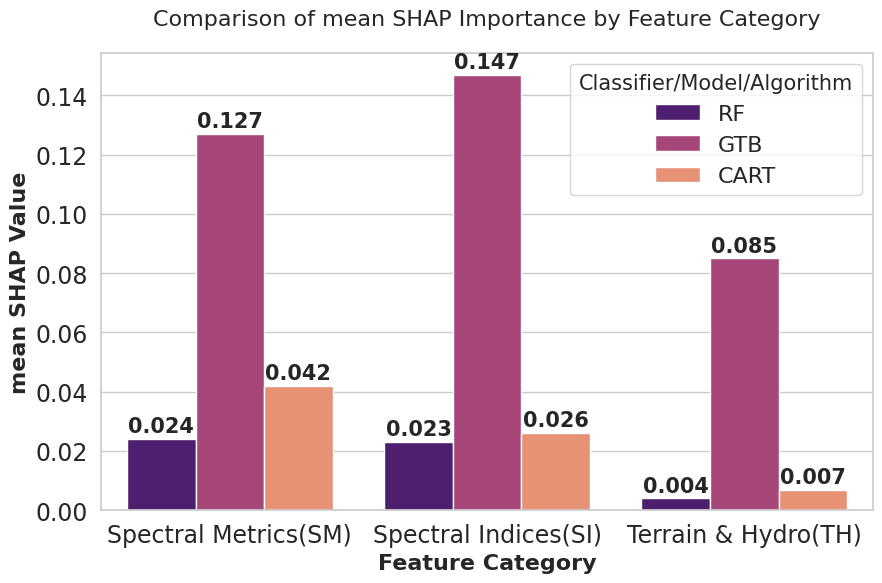

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the data from the user-provided table
data = {
    'Feature Category': ['Spectral Metrics(SM)', 'Spectral Indices(SI)', 'Terrain & Hydro(TH)'],
    'RF': [0.024, 0.023, 0.004],
    'GTB': [0.127, 0.147, 0.085],
    'CART': [0.042, 0.026, 0.007]
}

summary_df = pd.DataFrame(data)

# 2. Reshape to long-form for Seaborn
summary_long = summary_df.melt(id_vars='Feature Category', var_name='Model', value_name='Avg SHAP Value')

# 3. Create the plot
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=summary_long, x='Feature Category', y='Avg SHAP Value', hue='Model', palette='magma')

# 4. Add labels and title with increased padding
plt.title('Comparison of mean SHAP Importance by Feature Category', fontsize=16, pad=20)
plt.ylabel('mean SHAP Value', fontsize=16, fontweight='bold')
plt.xlabel('Feature Category', fontsize=16, fontweight='bold')

# Increase legend label and title font size
plt.legend(title='Classifier/Model/Algorithm', prop={'size': 16}, title_fontsize=15)

# Increase font size of axis tick labels
ax.tick_params(axis='both', labelsize=17)

# Add value labels on top of bars for clarity with increased font size
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

## Global SHAP Importance Summary Visualization

This cell visualizes a summary of global SHAP importance using a heatmap. It takes predefined data (Global Total SHAP and Global mean SHAP for different Feature Categories) and displays these values using color intensity. Cells with no data (NaN) are masked and shown as a dash '-', providing a clear and condensed overview of feature influence.

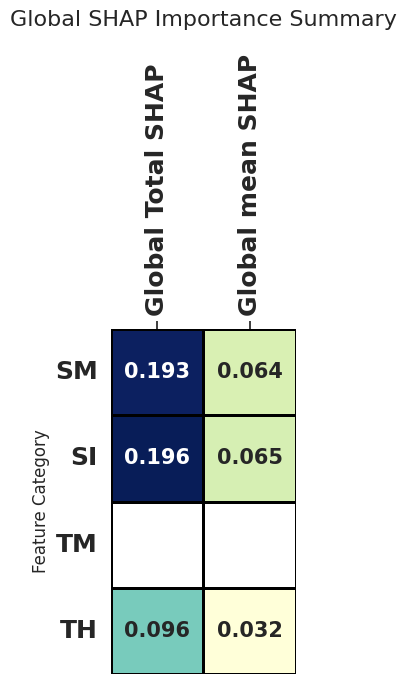

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the table data
table_data = {
    'Feature Category': ['SM', 'SI', 'TM', 'TH'],
    'Global Total SHAP': [0.193, 0.196, None, 0.096],
    'Global mean SHAP': [0.064, 0.065, None, 0.032]
}

# Prepare DataFrame (Features as index/rows, Metrics as columns)
table_df = pd.DataFrame(table_data).set_index('Feature Category')

# 2. Visualize as a styled table using Seaborn heatmap
plt.figure(figsize=(3, 7))
sns.set_theme(style="white")

# Mask for NaN values
mask = table_df.isnull()

# Plot heatmap
ax = sns.heatmap(table_df.fillna(0), annot=True, fmt=".3f", cmap="YlGnBu",
                 cbar=False, linewidths=2, linecolor='black',
                 mask=mask, annot_kws={"size": 15, "weight": "bold"})

# Replace zero/null placeholders with '-'
for text in ax.texts:
    if text.get_text() == "0.000":
        text.set_text("-")

plt.title('Global SHAP Importance Summary', fontsize=16, pad=20)
ax.xaxis.tick_top()
plt.xticks(fontsize=18, fontweight='bold', rotation=90)
plt.yticks(fontsize=18, fontweight='bold', rotation=0)
plt.tight_layout()
plt.show()